In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("data/Loan_Approval.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset loaded successfully!
Shape: (614, 13)

Columns:
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']

First 5 rows:


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


In [4]:
# Remove unnecessary ID column
df = df.drop("Loan_ID", axis=1)

# Fill missing categorical values with the most frequent value
categorical_columns = ["Gender", "Married", "Dependents", "Self_Employed"]

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Fill missing numerical values with the median
df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].median())
df["Loan_Amount_Term"] = df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].median())
df["Credit_History"] = df["Credit_History"].fillna(df["Credit_History"].mode()[0])

print("Data cleaning completed!")
print("Remaining missing values:")
print(df.isnull().sum())

Data cleaning completed!
Remaining missing values:
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [5]:
print("Cleaned dataset shape:", df.shape)
display(df.head())

Cleaned dataset shape: (614, 12)


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


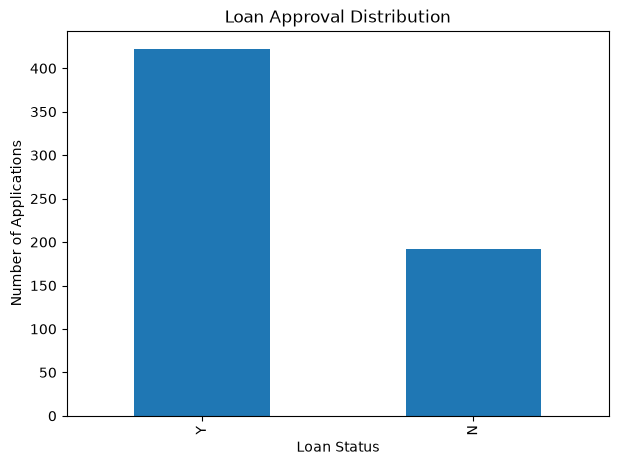

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

df["Loan_Status"].value_counts().plot(kind="bar")

plt.title("Loan Approval Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applications")

plt.show()

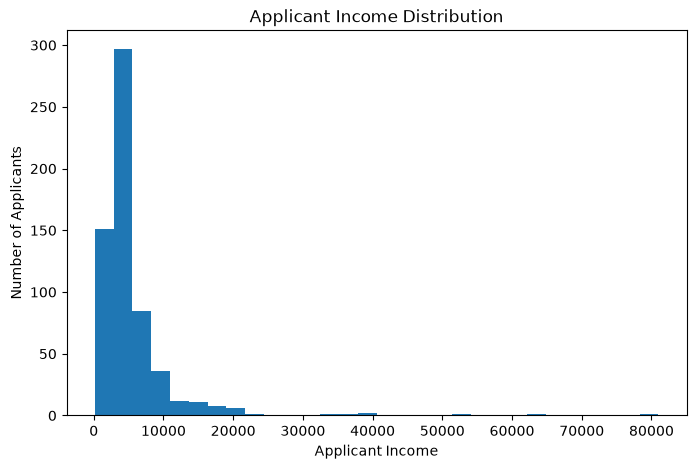

In [7]:
plt.figure(figsize=(8, 5))

plt.hist(df["ApplicantIncome"], bins=30)

plt.title("Applicant Income Distribution")
plt.xlabel("Applicant Income")
plt.ylabel("Number of Applicants")

plt.show()

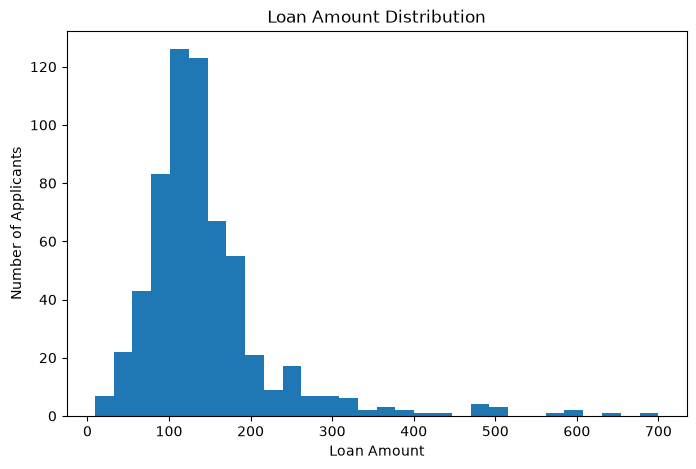

In [8]:
plt.figure(figsize=(8, 5))

plt.hist(df["LoanAmount"], bins=30)

plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Number of Applicants")

plt.show()

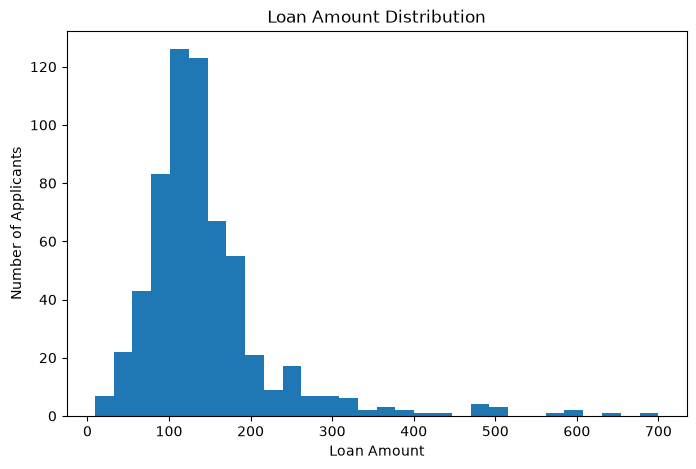

In [9]:
plt.figure(figsize=(8, 5))

plt.hist(df["LoanAmount"], bins=30)

plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Number of Applicants")

plt.show()

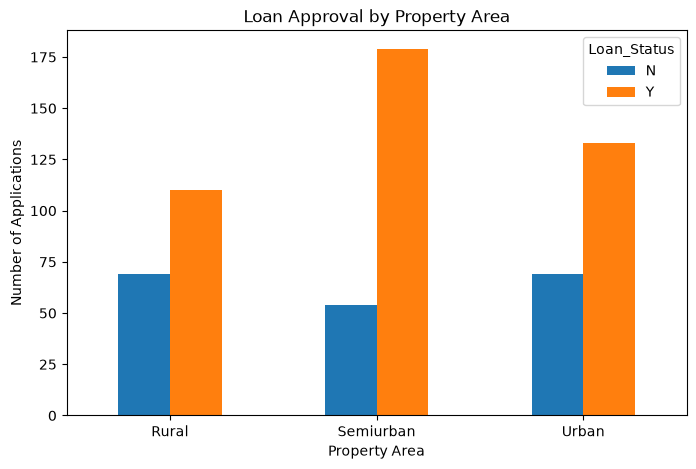

In [10]:
pd.crosstab(
    df["Property_Area"],
    df["Loan_Status"]
).plot(kind="bar", figsize=(8, 5))

plt.title("Loan Approval by Property Area")
plt.xlabel("Property Area")
plt.ylabel("Number of Applications")

plt.xticks(rotation=0)

plt.show()

In [11]:
# Separate features and target

X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"].map({
    "N": 0,
    "Y": 1
})

print("Features:")
print(X.columns.tolist())

print("\nTarget values:")
print(y.value_counts())

Features:
['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area']

Target values:
Loan_Status
1    422
0    192
Name: count, dtype: int64


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (491, 11)
Testing data : (123, 11)


In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Property_Area"
]

numeric_features = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

print("Preprocessor created successfully!")

Preprocessor created successfully!


In [14]:
# Separate features and target

X = df.drop("Loan_Status", axis=1)

y = df["Loan_Status"].map({
    "N": 0,
    "Y": 1
})

print("Features:")
print(X.columns.tolist())

print("\nTarget values:")
print(y.value_counts())

Features:
['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area']

Target values:
Loan_Status
1    422
0    192
Name: count, dtype: int64


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (491, 11)
Testing data : (123, 11)


In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Property_Area"
]

numeric_features = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

print("Preprocessor created successfully!")

Preprocessor created successfully!


In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Property_Area"
]

numeric_features = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

print("Preprocessor created successfully!")

Preprocessor created successfully!


In [18]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

logistic_model.fit(X_train, y_train)

y_pred_logistic = logistic_model.predict(X_test)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


c:\Users\divya\Desktop\Loan_Approval\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [19]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy_logistic = accuracy_score(
    y_test,
    y_pred_logistic
)

precision_logistic = precision_score(
    y_test,
    y_pred_logistic
)

recall_logistic = recall_score(
    y_test,
    y_pred_logistic
)

f1_logistic = f1_score(
    y_test,
    y_pred_logistic
)

print("Logistic Regression Performance")
print("--------------------------------")
print("Accuracy :", round(accuracy_logistic, 4))
print("Precision:", round(precision_logistic, 4))
print("Recall   :", round(recall_logistic, 4))
print("F1 Score :", round(f1_logistic, 4))

Logistic Regression Performance
--------------------------------
Accuracy : 0.8618
Precision: 0.84
Recall   : 0.9882
F1 Score : 0.9081


In [20]:
from sklearn.tree import DecisionTreeClassifier

tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(random_state=42))
    ]
)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [21]:
accuracy_tree = accuracy_score(y_test, y_pred_tree)
precision_tree = precision_score(y_test, y_pred_tree)
recall_tree = recall_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)

print("Decision Tree Performance")
print("-------------------------")
print("Accuracy :", round(accuracy_tree, 4))
print("Precision:", round(precision_tree, 4))
print("Recall   :", round(recall_tree, 4))
print("F1 Score :", round(f1_tree, 4))

Decision Tree Performance
-------------------------
Accuracy : 0.748
Precision: 0.8293
Recall   : 0.8
F1 Score : 0.8144


In [22]:
from sklearn.ensemble import RandomForestClassifier

forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

forest_model.fit(X_train, y_train)

y_pred_forest = forest_model.predict(X_test)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [23]:
accuracy_forest = accuracy_score(
    y_test,
    y_pred_forest
)

precision_forest = precision_score(
    y_test,
    y_pred_forest
)

recall_forest = recall_score(
    y_test,
    y_pred_forest
)

f1_forest = f1_score(
    y_test,
    y_pred_forest
)

print("Random Forest Performance")
print("-------------------------")
print("Accuracy :", round(accuracy_forest, 4))
print("Precision:", round(precision_forest, 4))
print("Recall   :", round(recall_forest, 4))
print("F1 Score :", round(f1_forest, 4))

Random Forest Performance
-------------------------
Accuracy : 0.813
Precision: 0.837
Recall   : 0.9059
F1 Score : 0.8701


In [24]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_logistic,
        accuracy_tree,
        accuracy_forest
    ],
    "Precision": [
        precision_logistic,
        precision_tree,
        precision_forest
    ],
    "Recall": [
        recall_logistic,
        recall_tree,
        recall_forest
    ],
    "F1 Score": [
        f1_logistic,
        f1_tree,
        f1_forest
    ]
})

results = results.round(4)

display(results)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8618,0.8400,0.9882,0.9081
1,Decision Tree,0.7480,0.8293,0.8000,0.8144
2,Random Forest,0.8130,0.8370,0.9059,0.8701


In [25]:
best_model_name = results.loc[
    results["F1 Score"].idxmax(),
    "Model"
]

best_f1 = results["F1 Score"].max()

print("Best Model:", best_model_name)
print("Best F1 Score:", best_f1)

Best Model: Logistic Regression
Best F1 Score: 0.9081


In [26]:
import joblib

model_mapping = {
    "Logistic Regression": logistic_model,
    "Decision Tree": tree_model,
    "Random Forest": forest_model
}

best_model = model_mapping[best_model_name]

joblib.dump(
    best_model,
    "models/loan_approval_model.pkl"
)

results.to_csv(
    "models/model_comparison.csv",
    index=False
)

print("Best Model:", best_model_name)
print("Best F1 Score:", best_f1)
print("Model saved successfully!")
print("Saved to: models/loan_approval_model.pkl")
print("Comparison saved to: models/model_comparison.csv")

Best Model: Logistic Regression
Best F1 Score: 0.9081
Model saved successfully!
Saved to: models/loan_approval_model.pkl
Comparison saved to: models/model_comparison.csv
